# 영상정보처리 19강 · [실습] 카메라 캘리브레이션과 왜곡 보정
**2026-1 Visual Computing | 교수 김하연**

17강(핀홀 카메라 모델 + 렌즈 왜곡)과 18강(캘리브레이션 이론)에서 **정의**한 카메라 모델을,
이번 실습에서는 코드로 직접 **추정**하고 **검증**한다.

## 0. 환경 준비

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)
np.set_printoptions(precision=3, suppress=True)

# matplotlib 그림 안의 글자는 폰트 호환을 위해 영문으로 표기한다.

OpenCV: 4.13.0


## 1. 카메라 모델 한 줄 회수 (18강 슬라이드 2)

전체 투영 파이프라인:

```
월드 (Xw,Yw,Zw) --[R|t]--> 카메라 (Xc,Yc,Zc) --÷Zc--> 정규화 (x,y) --D--> 왜곡 (xd,yd) --K--> 픽셀 (u,v)
```

완전한 카메라 = `K`(내부 5) + `[R|t]`(외부 6) + `D`(왜곡 5).
캘리브레이션의 목표는 `K`와 `D`를 알아내는 것.
`[R|t]`는 사진마다 다르지만, `K`와 `D`는 같은 카메라라면 모든 사진에서 동일하다는 점이 핵심이다.

## 2. 캘리브레이션 데이터 준비

체스보드 설정: 안쪽 코너 9×6, 한 칸 25mm (18강 슬라이드 4).
체스보드는 평면이라 모든 코너의 `Z = 0`으로 단순화된다.

In [3]:
# ---- 캘리브레이션 설정 ----
PATTERN   = (9, 6)     # 안쪽 코너 개수 (가로, 세로)
SQUARE_MM = 25.0       # 한 칸 실제 크기 (mm)

USE_SYNTHETIC = True                 # True: 합성 영상 / False: 실제 사진
IMAGE_GLOB    = "calib_images/*.jpg" # 실제 사진 경로 (USE_SYNTHETIC=False일 때)

# 안쪽 코너의 3D 월드 좌표 (Z=0 평면). 모든 사진에서 공통.
objp = np.zeros((PATTERN[0] * PATTERN[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:PATTERN[0], 0:PATTERN[1]].T.reshape(-1, 2) * SQUARE_MM
print("3D 코너 개수:", len(objp))
print("처음 3개 좌표(mm):\n", objp[:3])

3D 코너 개수: 54
처음 3개 좌표(mm):
 [[ 0.  0.  0.]
 [25.  0.  0.]
 [50.  0.  0.]]


### 2-A. (선택) 실제 촬영 사진 사용

직접 찍은 사진으로 하려면 위 셀에서 `USE_SYNTHETIC = False`로 두고 `IMAGE_GLOB` 경로만 맞춘다.
촬영 가이드(18강 슬라이드 9): 다양한 각도/거리, 영상 가장자리까지 골고루, 10~20장.

In [4]:
import glob
images = []
if not USE_SYNTHETIC:
    for p in sorted(glob.glob(IMAGE_GLOB)):
        im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if im is not None:
            images.append(im)
    print("불러온 사진:", len(images))

### 2-B. 합성 체스보드 영상 생성 (단독 실행용)

가상 카메라(`K_true`, `dist_true`)로 체스보드를 여러 자세에서 "촬영"한 영상을 만든다.
방식: 평면 체스보드 텍스처를 호모그래피로 투영한 뒤, Brown-Conrady 왜곡을 픽셀 단위로 입힌다.

In [5]:
if USE_SYNTHETIC:
    rng = np.random.default_rng(7)
    IMG_W, IMG_H = 1280, 720

    # 정답 카메라 (이 값을 캘리브레이션으로 복원하는 것이 목표)
    K_true    = np.array([[900., 0., 645.],
                          [0., 900., 365.],
                          [0., 0.,   1.]])
    dist_true = np.array([-0.30, 0.12, 0.0010, 0.0008, 0.0])  # k1 k2 p1 p2 k3

    nx, ny = PATTERN[0] + 1, PATTERN[1] + 1   # 전체 칸 수 10×7

    # 체스보드 텍스처 (흰 여백 포함)
    ppm, margin_mm = 6, 35
    TW = int((nx*SQUARE_MM + 2*margin_mm) * ppm)
    TH = int((ny*SQUARE_MM + 2*margin_mm) * ppm)
    tex = np.full((TH, TW), 255, np.uint8)
    for r in range(ny):
        for c in range(nx):
            if (r + c) % 2 == 0:
                x0 = int((margin_mm + c*SQUARE_MM)*ppm); x1 = int((margin_mm + (c+1)*SQUARE_MM)*ppm)
                y0 = int((margin_mm + r*SQUARE_MM)*ppm); y1 = int((margin_mm + (r+1)*SQUARE_MM)*ppm)
                tex[y0:y1, x0:x1] = 0

    # 텍스처 픽셀 -> 보드 mm (코너 좌표계 중심에 맞춤)
    A = np.array([[1.0/ppm, 0, -(margin_mm + nx*SQUARE_MM/2.0)],
                  [0, 1.0/ppm, -(margin_mm + ny*SQUARE_MM/2.0)],
                  [0, 0, 1.0]])
    objp_c = objp.copy()                       # 렌더링용으로 코너를 중심 정렬
    objp_c[:, 0] -= objp_c[:, 0].mean()
    objp_c[:, 1] -= objp_c[:, 1].mean()

    def add_distortion(img, K, D):
        # 왜곡 입히기: 출력(왜곡)픽셀 -> 입력(이상)픽셀을 undistortPoints로 역산해 remap
        h, w = img.shape[:2]
        yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
        pts = np.stack([xx.ravel(), yy.ravel()], 1).reshape(-1, 1, 2)
        src = cv2.undistortPoints(pts, K, D, P=K)
        mx = src[:, 0, 0].reshape(h, w).astype(np.float32)
        my = src[:, 0, 1].reshape(h, w).astype(np.float32)
        return cv2.remap(img, mx, my, cv2.INTER_LINEAR, borderValue=255)

    def make_view(rvec, t):
        R, _ = cv2.Rodrigues(rvec)
        H_ideal = K_true @ np.hstack([R[:, :2], t.reshape(3, 1)])  # 평면 -> 이상 픽셀
        ideal = cv2.warpPerspective(tex, H_ideal @ A, (IMG_W, IMG_H), borderValue=255)
        return add_distortion(ideal, K_true, dist_true)

    # 다양한 각도/거리/위치로 15장 생성
    images = []
    for _ in range(15):
        rvec = np.array([rng.uniform(-0.45, 0.45), rng.uniform(-0.45, 0.45), rng.uniform(-0.30, 0.30)])
        t    = np.array([rng.uniform(-60, 60), rng.uniform(-40, 40), rng.uniform(380, 620)])
        images.append(make_view(rvec, t))

    print("생성한 합성 영상:", len(images), "장,  크기:", images[0].shape[::-1])

생성한 합성 영상: 15 장,  크기: (1280, 720)


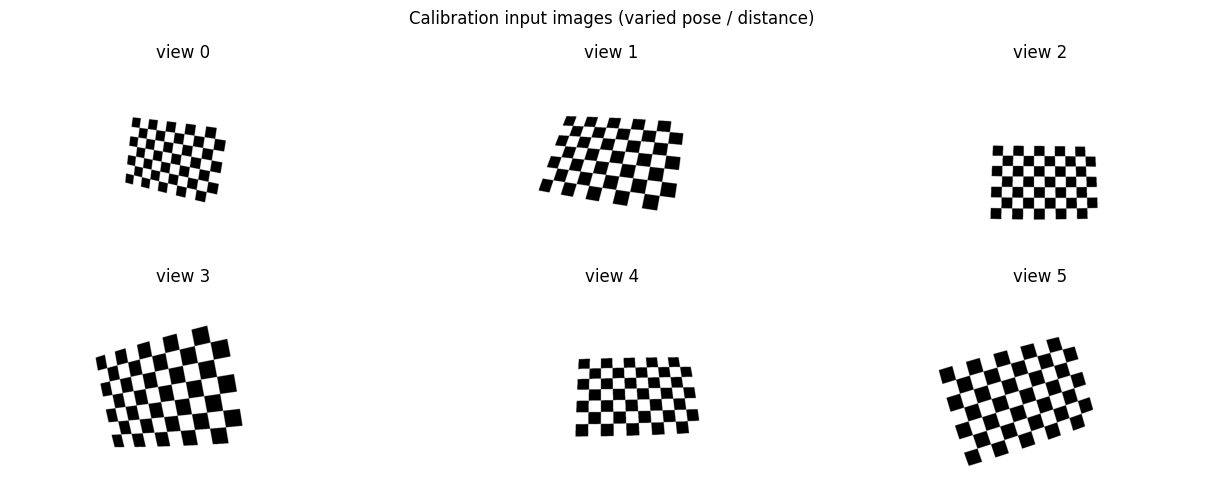

In [6]:
# 생성된(또는 불러온) 영상 미리보기
n = min(6, len(images))
plt.figure(figsize=(13, 5))
for i in range(n):
    plt.subplot(2, 3, i + 1); plt.imshow(images[i], cmap="gray")
    plt.title(f"view {i}"); plt.axis("off")
plt.suptitle("Calibration input images (varied pose / distance)")
plt.tight_layout(); plt.show()

## 3. 체스보드 코너 검출

`findChessboardCorners`로 코너를 찾고 `cornerSubPix`로 서브픽셀 정밀도까지 끌어올린다.
사진 한 장마다 (3D 좌표 `objp`, 검출 픽셀 `corners`) 한 쌍이 만들어진다.

In [20]:
flags = (cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK)
crit  = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objpoints, imgpoints, used = [], [], []   # 3D점, 2D점, 검출 성공한 영상 인덱스
for i, im in enumerate(images):
    ok, corners = cv2.findChessboardCorners(im, PATTERN, flags)
    if ok:
        corners = cv2.cornerSubPix(im, corners, (11, 11), (-1, -1), crit)  # 서브픽셀 보정
        objpoints.append(objp); imgpoints.append(corners); used.append(i)

print(f"코너 검출 성공: {len(used)} / {len(images)} 장")

코너 검출 성공: 15 / 15 장


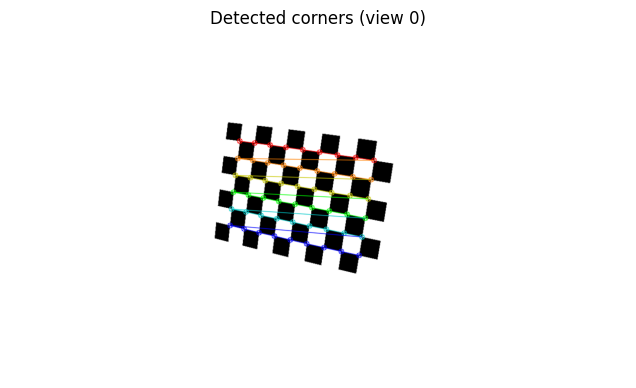

In [21]:
# 검출 결과를 한 장에 그려서 확인
i = used[0]
vis = cv2.cvtColor(images[i], cv2.COLOR_GRAY2BGR)
cv2.drawChessboardCorners(vis, PATTERN, imgpoints[0], True)
plt.figure(figsize=(8, 4.5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected corners (view {i})"); plt.axis("off"); plt.show()

## 4. 캘리브레이션 실행

`cv2.calibrateCamera`가 모든 사진의 (3D, 2D) 쌍을 모아 **재투영 오차를 최소화**하는
`K`, `D`, 그리고 각 사진의 `[R|t]`를 한 번에 추정한다 (18강 슬라이드 7).
합성 데이터의 `k3`은 0이므로 `CALIB_FIX_K3`로 고정해 계수를 간결하게 둔다.

In [22]:
image_size = images[0].shape[::-1]   # (w, h)
calib_flags = cv2.CALIB_FIX_K3 if USE_SYNTHETIC else 0

rms, K, D, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None, flags=calib_flags)

print("RMS 재투영 오차: %.4f px" % rms)
print("\nK (내부 파라미터):\n", K)
print("\nD (왜곡 계수) [k1 k2 p1 p2 k3]:\n", D.ravel())

if USE_SYNTHETIC:
    print("\n--- 정답과 비교 ---")
    print("K_true:\n", K_true)
    print("dist_true:", dist_true)

RMS 재투영 오차: 0.1649 px

K (내부 파라미터):
 [[902.023   0.    644.436]
 [  0.    901.792 365.49 ]
 [  0.      0.      1.   ]]

D (왜곡 계수) [k1 k2 p1 p2 k3]:
 [-0.305  0.155  0.001  0.001  0.   ]

--- 정답과 비교 ---
K_true:
 [[900.   0. 645.]
 [  0. 900. 365.]
 [  0.   0.   1.]]
dist_true: [-0.3    0.12   0.001  0.001  0.   ]


## 5. K 행렬 해석 (18강 슬라이드 10)

추정된 숫자에서 카메라의 정체를 읽어낸다: 픽셀 단위 초점거리, 주점, 시야각(FOV).

In [23]:
fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]
w, h   = image_size
fov_x  = 2 * np.degrees(np.arctan(w / (2 * fx)))
fov_y  = 2 * np.degrees(np.arctan(h / (2 * fy)))

print(f"fx, fy        = {fx:.1f}, {fy:.1f} px   (정사각 픽셀이면 둘이 비슷)")
print(f"주점 (cx, cy) = ({cx:.1f}, {cy:.1f})")
print(f"영상 중심     = ({w/2:.1f}, {h/2:.1f})   -> 주점은 중심 근처여야 정상")
print(f"시야각 FOV    = 가로 {fov_x:.1f}도, 세로 {fov_y:.1f}도")

# 비정상 패턴 점검 (18강 슬라이드 10)
if abs(cx - w/2) > 0.1*w or abs(cy - h/2) > 0.1*h:
    print("경고: 주점이 중심에서 많이 벗어남 -> 캘리브레이션 실패 의심")
if abs(fx - fy) / max(fx, fy) > 0.1:
    print("경고: fx와 fy 차이가 큼 -> 픽셀 비대칭 또는 오류 의심")

fx, fy        = 902.0, 901.8 px   (정사각 픽셀이면 둘이 비슷)
주점 (cx, cy) = (644.4, 365.5)
영상 중심     = (640.0, 360.0)   -> 주점은 중심 근처여야 정상
시야각 FOV    = 가로 70.7도, 세로 43.5도


## 6. 재투영 오차 분석 (18강 슬라이드 7~8)

추정한 모델로 3D 코너를 다시 투영(reproject)해, 실제 검출 픽셀과 얼마나 가까운지를 본다.
사진별 평균 오차가 고르게 작으면 좋은 캘리브레이션이다.

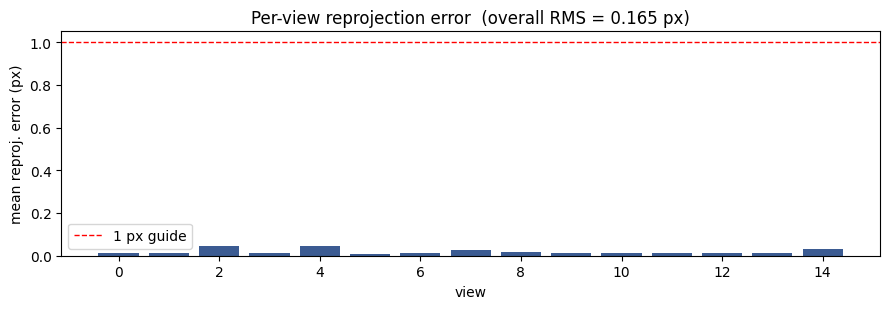

판정 기준: <1px 양호, 1~2px 보통, >3px 재촬영


In [24]:
errors = []
for i in range(len(objpoints)):
    proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, D)
    e = cv2.norm(imgpoints[i], proj, cv2.NORM_L2) / len(proj)   # 평균 거리(px)
    errors.append(e)

plt.figure(figsize=(9, 3.2))
plt.bar(range(len(errors)), errors, color="#3b5b92")
plt.axhline(1.0, color="r", ls="--", lw=1, label="1 px guide")
plt.xlabel("view"); plt.ylabel("mean reproj. error (px)")
plt.title(f"Per-view reprojection error  (overall RMS = {rms:.3f} px)")
plt.legend(); plt.tight_layout(); plt.show()
print("판정 기준: <1px 양호, 1~2px 보통, >3px 재촬영")

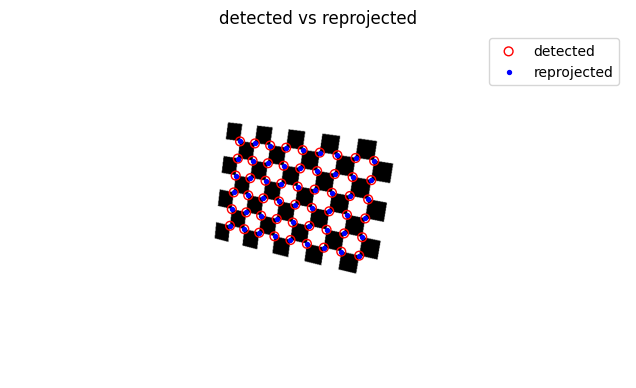

In [25]:
# 한 장에서 검출 픽셀(빨강) vs 모델 예측 픽셀(파랑) 겹쳐보기 (슬라이드 8)
i = 0
proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, D)
det = imgpoints[i].reshape(-1, 2); prj = proj.reshape(-1, 2)
plt.figure(figsize=(8, 4.5))
plt.imshow(images[used[i]], cmap="gray")
plt.scatter(det[:, 0], det[:, 1], s=40, facecolors="none", edgecolors="r", label="detected")
plt.scatter(prj[:, 0], prj[:, 1], s=8, c="b", label="reprojected")
plt.title("detected vs reprojected"); plt.legend(); plt.axis("off"); plt.show()

## 7. 왜곡 보정 (Undistortion) (18강 슬라이드 11)

`D`를 알면 왜곡 변환의 역을 풀 수 있다. `getOptimalNewCameraMatrix`로 보정 후 유효 영역을 잡고,
`undistort`로 휘어 보이던 직선을 다시 직선으로 만든다.

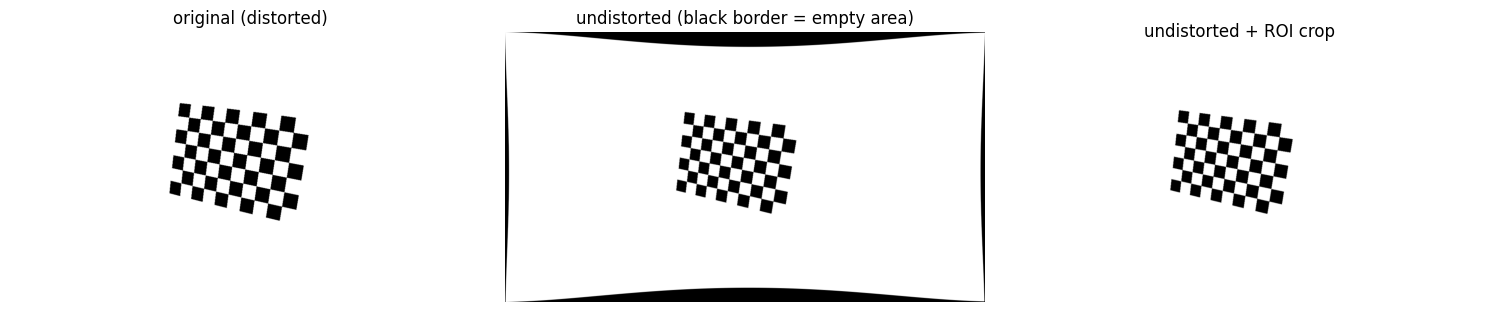

In [26]:
img = images[used[0]]
newK, roi = cv2.getOptimalNewCameraMatrix(K, D, image_size, alpha=1, newImgSize=image_size)
undist = cv2.undistort(img, K, D, None, newK)

# 보정 후 유효 영역(ROI)만 잘라낸 결과
x, y, ww, hh = roi
cropped = undist[y:y+hh, x:x+ww]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(img, cmap="gray");     ax[0].set_title("original (distorted)")
ax[1].imshow(undist, cmap="gray");  ax[1].set_title("undistorted (black border = empty area)")
ax[2].imshow(cropped, cmap="gray"); ax[2].set_title("undistorted + ROI crop")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

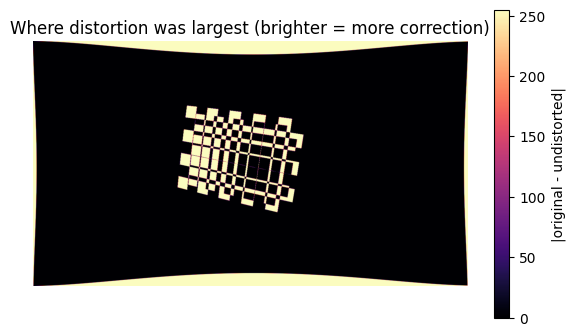

In [27]:
# 차이 영상: 보정 전후 픽셀이 얼마나 이동했는지 (가장자리에서 큼)
diff = cv2.absdiff(img, undist)
plt.figure(figsize=(7, 4))
plt.imshow(diff, cmap="magma"); plt.colorbar(label="|original - undistorted|")
plt.title("Where distortion was largest (brighter = more correction)")
plt.axis("off"); plt.show()